In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA COLLECTION AND MERGING

In [3]:
# Load exchange rate data
# USD is home currency, CAD is foreign currency
df_uc= pd.read_csv('USD_CAD.csv')

In [5]:
#Preview the dataset
from tabulate import tabulate
print(tabulate(df_uc, headers='keys', tablefmt='grid'))

+-----+--------------------+----------+
|     | observation_date   |   EXCAUS |
+=====+====================+==========+
|   0 | 1971-01-01         |   1.0118 |
+-----+--------------------+----------+
|   1 | 1971-02-01         |   1.0075 |
+-----+--------------------+----------+
|   2 | 1971-03-01         |   1.0064 |
+-----+--------------------+----------+
|   3 | 1971-04-01         |   1.0077 |
+-----+--------------------+----------+
|   4 | 1971-05-01         |   1.0087 |
+-----+--------------------+----------+
|   5 | 1971-06-01         |   1.0213 |
+-----+--------------------+----------+
|   6 | 1971-07-01         |   1.0213 |
+-----+--------------------+----------+
|   7 | 1971-08-01         |   1.013  |
+-----+--------------------+----------+
|   8 | 1971-09-01         |   1.013  |
+-----+--------------------+----------+
|   9 | 1971-10-01         |   1.0047 |
+-----+--------------------+----------+
|  10 | 1971-11-01         |   1.0039 |
+-----+--------------------+----------+


In [7]:
#Rename column name observation_date to DATE
df_uc.rename(columns={"observation_date": "DATE"}, inplace=True)

In [9]:
#Preview the datasets
print(df_uc.head())

         DATE  EXCAUS
0  1971-01-01  1.0118
1  1971-02-01  1.0075
2  1971-03-01  1.0064
3  1971-04-01  1.0077
4  1971-05-01  1.0087


In [11]:
# Convert the DATE column from "dd/mm/yy" format to a datetime object.
df_uc['DATE'] = pd.to_datetime(df_uc['DATE'], format='%Y-%m-%d')
print(df_uc.head())

        DATE  EXCAUS
0 1971-01-01  1.0118
1 1971-02-01  1.0075
2 1971-03-01  1.0064
3 1971-04-01  1.0077
4 1971-05-01  1.0087


In [13]:
#Filteing rows to only dates from Jan-2010) to Dec-2020.
start_date = pd.to_datetime("2010-01-01")
end_date   = pd.to_datetime("2020-12-31")
df_uc = df_uc[(df_uc['DATE'] >= start_date) & (df_uc['DATE'] <= end_date)]

# Sort the  DATE column in ascending order.
df_uc.sort_values(by='DATE', inplace=True)

# Reformatting the DATE columnto MMM-YYYY format.
df_uc['DATE'] = df_uc['DATE'].dt.strftime('%b-%Y')

#Rename column name EXCAUS to USD_CAD
df_uc.rename(columns={"EXCAUS": "USD_CAD"}, inplace=True)
             
# Preview cleaned Data
from tabulate import tabulate
print(tabulate(df_uc, headers='keys', tablefmt='grid'))

+-----+----------+-----------+
|     | DATE     |   USD_CAD |
+=====+==========+===========+
| 468 | Jan-2010 |    1.0438 |
+-----+----------+-----------+
| 469 | Feb-2010 |    1.0572 |
+-----+----------+-----------+
| 470 | Mar-2010 |    1.0229 |
+-----+----------+-----------+
| 471 | Apr-2010 |    1.0052 |
+-----+----------+-----------+
| 472 | May-2010 |    1.0403 |
+-----+----------+-----------+
| 473 | Jun-2010 |    1.0376 |
+-----+----------+-----------+
| 474 | Jul-2010 |    1.0422 |
+-----+----------+-----------+
| 475 | Aug-2010 |    1.0404 |
+-----+----------+-----------+
| 476 | Sep-2010 |    1.033  |
+-----+----------+-----------+
| 477 | Oct-2010 |    1.0179 |
+-----+----------+-----------+
| 478 | Nov-2010 |    1.0129 |
+-----+----------+-----------+
| 479 | Dec-2010 |    1.0081 |
+-----+----------+-----------+
| 480 | Jan-2011 |    0.9939 |
+-----+----------+-----------+
| 481 | Feb-2011 |    0.9876 |
+-----+----------+-----------+
| 482 | Mar-2011 |    0.9766 |
+-----+-

In [15]:
#load dataset consumer price index Canada
df_ca= pd.read_csv('CPI_CAN.csv')

In [17]:
#Preview the dataset
from tabulate import tabulate
print(tabulate(df_ca, headers='keys', tablefmt='grid'))

+-----+--------------------+-------------------+
|     | observation_date   |   CPALCY01CAM661N |
+=====+====================+===================+
|   0 | 1961-01-01         |           13.4288 |
+-----+--------------------+-------------------+
|   1 | 1961-02-01         |           13.4288 |
+-----+--------------------+-------------------+
|   2 | 1961-03-01         |           13.3779 |
+-----+--------------------+-------------------+
|   3 | 1961-04-01         |           13.3439 |
+-----+--------------------+-------------------+
|   4 | 1961-05-01         |           13.259  |
+-----+--------------------+-------------------+
|   5 | 1961-06-01         |           13.31   |
+-----+--------------------+-------------------+
|   6 | 1961-07-01         |           13.3269 |
+-----+--------------------+-------------------+
|   7 | 1961-08-01         |           13.3609 |
+-----+--------------------+-------------------+
|   8 | 1961-09-01         |           13.4288 |
+-----+-------------

In [19]:
#Rename column name observation_date to DATE
df_ca.rename(columns={"observation_date": "DATE"}, inplace=True)

In [21]:
#Preview the datasets
print(df_ca.head())

         DATE  CPALCY01CAM661N
0  1961-01-01        13.428804
1  1961-02-01        13.428804
2  1961-03-01        13.377873
3  1961-04-01        13.343919
4  1961-05-01        13.259034


In [23]:
# Convert the DATE column from "dd/mm/yy" format to a datetime object.
df_ca['DATE'] = pd.to_datetime(df_ca['DATE'], format='%Y-%m-%d')
print(df_ca.head())

        DATE  CPALCY01CAM661N
0 1961-01-01        13.428804
1 1961-02-01        13.428804
2 1961-03-01        13.377873
3 1961-04-01        13.343919
4 1961-05-01        13.259034


In [25]:
# Filteing rows to only dates from Jan-2010 to Dec-2020.
start_date = pd.to_datetime("2010-01-01")
end_date   = pd.to_datetime("2020-12-31")
df_ca = df_ca[(df_ca['DATE'] >= start_date) & (df_ca['DATE'] <= end_date)]

# Sort the  DATE column in ascending order.
df_ca.sort_values(by='DATE', inplace=True)

# Reformatting the DATE columnto MMM-YYYY format.
df_ca['DATE'] = df_ca['DATE'].dt.strftime('%b-%Y')

# Rename "CPALCY01CAM661N" column to "Can_CPI"
df_ca.rename(columns={"CPALCY01CAM661N": "Can_CPI"}, inplace=True)

# Preview cleaned Data
from tabulate import tabulate
print(tabulate(df_ca, headers='keys', tablefmt='grid'))

+-----+----------+-----------+
|     | DATE     |   Can_CPI |
+=====+==========+===========+
| 588 | Jan-2010 |   91.2791 |
+-----+----------+-----------+
| 589 | Feb-2010 |   91.4392 |
+-----+----------+-----------+
| 590 | Mar-2010 |   91.6795 |
+-----+----------+-----------+
| 591 | Apr-2010 |   91.9197 |
+-----+----------+-----------+
| 592 | May-2010 |   91.9997 |
+-----+----------+-----------+
| 593 | Jun-2010 |   91.9197 |
+-----+----------+-----------+
| 594 | Jul-2010 |   91.6795 |
+-----+----------+-----------+
| 595 | Aug-2010 |   91.6795 |
+-----+----------+-----------+
| 596 | Sep-2010 |   91.9197 |
+-----+----------+-----------+
| 597 | Oct-2010 |   92.32   |
+-----+----------+-----------+
| 598 | Nov-2010 |   92.5602 |
+-----+----------+-----------+
| 599 | Dec-2010 |   92.7204 |
+-----+----------+-----------+
| 600 | Jan-2011 |   93.1207 |
+-----+----------+-----------+
| 601 | Feb-2011 |   93.2808 |
+-----+----------+-----------+
| 602 | Mar-2011 |   94.562  |
+-----+-

In [29]:
#load dataset consumer price index USA
df_us= pd.read_csv('CPI_US.csv')

In [31]:
#Preview
from tabulate import tabulate
print(tabulate(df_us, headers='keys', tablefmt='grid'))

+-----+--------------------+------------+
|     | observation_date   |   CPIAUCSL |
+=====+====================+============+
|   0 | 01/01/47           |     21.48  |
+-----+--------------------+------------+
|   1 | 01/02/47           |     21.62  |
+-----+--------------------+------------+
|   2 | 01/03/47           |     22     |
+-----+--------------------+------------+
|   3 | 01/04/47           |     22     |
+-----+--------------------+------------+
|   4 | 01/05/47           |     21.95  |
+-----+--------------------+------------+
|   5 | 01/06/47           |     22.08  |
+-----+--------------------+------------+
|   6 | 01/07/47           |     22.23  |
+-----+--------------------+------------+
|   7 | 01/08/47           |     22.4   |
+-----+--------------------+------------+
|   8 | 01/09/47           |     22.84  |
+-----+--------------------+------------+
|   9 | 01/10/47           |     22.91  |
+-----+--------------------+------------+
|  10 | 01/11/47           |     2

In [33]:
#Rename column name observation_date to DATE
df_us.rename(columns={"observation_date": "DATE"}, inplace=True)

In [35]:
print(df_us.head())

       DATE  CPIAUCSL
0  01/01/47     21.48
1  01/02/47     21.62
2  01/03/47     22.00
3  01/04/47     22.00
4  01/05/47     21.95


In [37]:
# Convert the 'DATE' column from "dd/mm/yy" format to a datetime object.
df_us['DATE'] = pd.to_datetime(df_us['DATE'], format='%d/%m/%y')
print(df_us.head())

        DATE  CPIAUCSL
0 2047-01-01     21.48
1 2047-02-01     21.62
2 2047-03-01     22.00
3 2047-04-01     22.00
4 2047-05-01     21.95


In [39]:
# Fix incorrect years (2047 instead of 1947)
df_us['DATE'] = df_us['DATE'].apply(
    lambda x: x.replace(year=x.year - 100) if x.year > 2025 else x
)

# Preview the corrected data
print(df_us.head())

        DATE  CPIAUCSL
0 1947-01-01     21.48
1 1947-02-01     21.62
2 1947-03-01     22.00
3 1947-04-01     22.00
4 1947-05-01     21.95


In [41]:
# Filteing rows to only dates from Jan-2010 to Dec-2020.
start_date = pd.to_datetime("2010-01-01")
end_date   = pd.to_datetime("2020-12-31")
df_us = df_us[(df_us['DATE'] >= start_date) & (df_us['DATE'] <= end_date)].copy()

# Sort the  DATE column in ascending order.
df_us.sort_values(by='DATE', inplace=True)

# Reformatting the DATE columnto MMM-YYYY format.
df_us['DATE'] = df_us['DATE'].dt.strftime('%b-%Y')

#Rename column name CPIAUCSL to Us_CPI
df_us.rename(columns={"CPIAUCSL": "Us_CPI"}, inplace=True)
            
# Preview cleaned Data
from tabulate import tabulate
print(tabulate(df_us, headers='keys', tablefmt='grid'))

+-----+----------+----------+
|     | DATE     |   Us_CPI |
+=====+==========+==========+
| 756 | Jan-2010 |  217.488 |
+-----+----------+----------+
| 757 | Feb-2010 |  217.281 |
+-----+----------+----------+
| 758 | Mar-2010 |  217.353 |
+-----+----------+----------+
| 759 | Apr-2010 |  217.403 |
+-----+----------+----------+
| 760 | May-2010 |  217.29  |
+-----+----------+----------+
| 761 | Jun-2010 |  217.199 |
+-----+----------+----------+
| 762 | Jul-2010 |  217.605 |
+-----+----------+----------+
| 763 | Aug-2010 |  217.923 |
+-----+----------+----------+
| 764 | Sep-2010 |  218.275 |
+-----+----------+----------+
| 765 | Oct-2010 |  219.035 |
+-----+----------+----------+
| 766 | Nov-2010 |  219.59  |
+-----+----------+----------+
| 767 | Dec-2010 |  220.472 |
+-----+----------+----------+
| 768 | Jan-2011 |  221.187 |
+-----+----------+----------+
| 769 | Feb-2011 |  221.898 |
+-----+----------+----------+
| 770 | Mar-2011 |  223.046 |
+-----+----------+----------+
| 771 | Ap

In [43]:
# Merging the dataset  with DATE as base  (only common dates remain)
merged_df = pd.merge(df_us, df_uc, on='DATE', how='inner')
merged_df = pd.merge(merged_df, df_ca, on='DATE', how='inner')

In [45]:
#Preview
from tabulate import tabulate
print(tabulate(merged_df, headers='keys', tablefmt='grid'))

+-----+----------+----------+-----------+-----------+
|     | DATE     |   Us_CPI |   USD_CAD |   Can_CPI |
+=====+==========+==========+===========+===========+
|   0 | Jan-2010 |  217.488 |    1.0438 |   91.2791 |
+-----+----------+----------+-----------+-----------+
|   1 | Feb-2010 |  217.281 |    1.0572 |   91.4392 |
+-----+----------+----------+-----------+-----------+
|   2 | Mar-2010 |  217.353 |    1.0229 |   91.6795 |
+-----+----------+----------+-----------+-----------+
|   3 | Apr-2010 |  217.403 |    1.0052 |   91.9197 |
+-----+----------+----------+-----------+-----------+
|   4 | May-2010 |  217.29  |    1.0403 |   91.9997 |
+-----+----------+----------+-----------+-----------+
|   5 | Jun-2010 |  217.199 |    1.0376 |   91.9197 |
+-----+----------+----------+-----------+-----------+
|   6 | Jul-2010 |  217.605 |    1.0422 |   91.6795 |
+-----+----------+----------+-----------+-----------+
|   7 | Aug-2010 |  217.923 |    1.0404 |   91.6795 |
+-----+----------+----------

INITIAL EDA (RAW DATA)

In [47]:
# Checking data types
print("\nData Types and Non-null Counts:")
print(merged_df.info())


Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DATE     132 non-null    object 
 1   Us_CPI   132 non-null    float64
 2   USD_CAD  132 non-null    float64
 3   Can_CPI  132 non-null    float64
dtypes: float64(3), object(1)
memory usage: 4.3+ KB
None


In [49]:
#statistics for numeric columns
print("\nDescriptive Statistics:")
print(merged_df.describe())


Descriptive Statistics:
           Us_CPI     USD_CAD     Can_CPI
count  132.000000  132.000000  132.000000
mean   239.089818    1.183613   99.835009
std     12.288652    0.146690    4.538391
min    217.199000    0.955300   91.279109
25%    231.169500    1.027200   96.603723
50%    237.498000    1.246400  100.086742
75%    249.739500    1.319300  103.429639
max    262.045000    1.420800  107.853473


In [51]:
# Checking for missing values in each column
print("\nMissing Values Per Column:")
print(merged_df.isnull().sum())


Missing Values Per Column:
DATE       0
Us_CPI     0
USD_CAD    0
Can_CPI    0
dtype: int64


In [53]:
# Converting the DATE column as it is an object(i.e string ) to datetime necessary for plotting
merged_df['DATE'] = pd.to_datetime(merged_df['DATE'], format='%b-%Y')

<Figure size 1400x600 with 0 Axes>

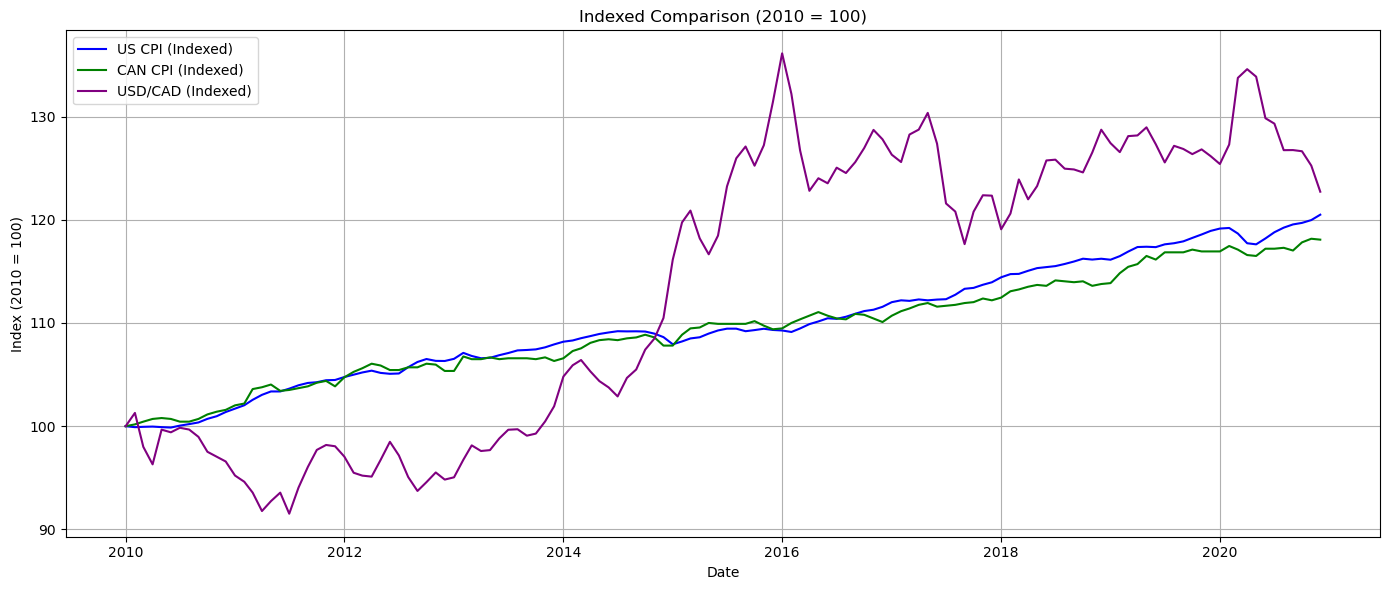

In [55]:
# Plot to show the US CPI, Can CPI, and USD/CAN exchange rate over time.
import matplotlib.dates as mdates
plt.figure(figsize=(14, 6))

#Normalizing All Series (Index = 100 at 2010) brings all values to a comparable scale
merged_df['CPI_US_norm'] = (merged_df['Us_CPI'] / merged_df['Us_CPI'].iloc[0]) * 100
merged_df['CPI_CAN_norm'] = (merged_df['Can_CPI'] / merged_df['Can_CPI'].iloc[0]) * 100
merged_df['USD_CAD_norm'] = (merged_df['USD_CAD'] / merged_df['USD_CAD'].iloc[0]) * 100

plt.figure(figsize=(14, 6))
plt.plot(merged_df['DATE'], merged_df['CPI_US_norm'], label='US CPI (Indexed)', color='blue')
plt.plot(merged_df['DATE'], merged_df['CPI_CAN_norm'], label='CAN CPI (Indexed)', color='green')
plt.plot(merged_df['DATE'], merged_df['USD_CAD_norm'], label='USD/CAD (Indexed)', color='purple')
plt.title('Indexed Comparison (2010 = 100)')
plt.xlabel('Date')
plt.ylabel('Index (2010 = 100)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


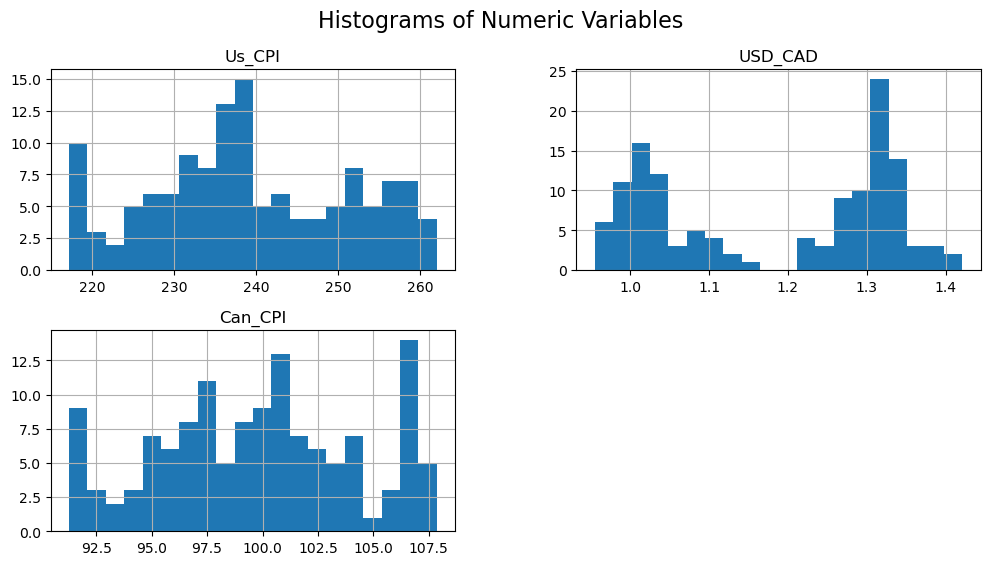

In [57]:
#histogram for the numeric columns to check for distribution.
numeric_cols = ['Us_CPI', 'USD_CAD', 'Can_CPI']
merged_df[numeric_cols].hist(bins=20, figsize=(12, 6))
plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.show()

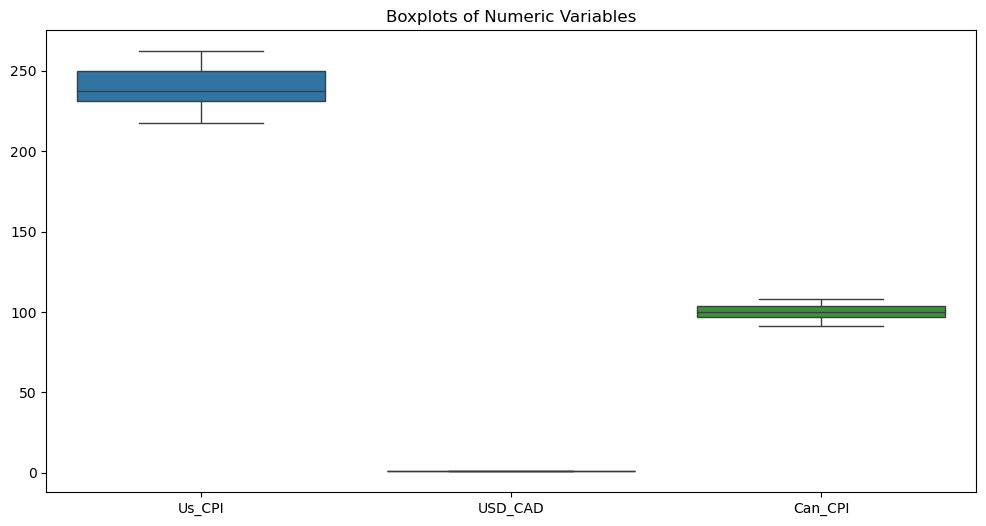

In [59]:
# boxplots to detect potential outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_df[numeric_cols])
plt.title("Boxplots of Numeric Variables")
plt.show()

In [61]:
# Dataset Preview after initial EDA
print("\nDataset Preview :")
print(merged_df.head())
print(merged_df.tail())


Dataset Preview :
        DATE   Us_CPI  USD_CAD    Can_CPI  CPI_US_norm  CPI_CAN_norm  \
0 2010-01-01  217.488   1.0438  91.279109   100.000000    100.000000   
1 2010-02-01  217.281   1.0572  91.439247    99.904822    100.175439   
2 2010-03-01  217.353   1.0229  91.679456    99.937928    100.438596   
3 2010-04-01  217.403   1.0052  91.919664    99.960917    100.701754   
4 2010-05-01  217.290   1.0403  91.999733    99.908960    100.789474   

   USD_CAD_norm  
0    100.000000  
1    101.283771  
2     97.997701  
3     96.301974  
4     99.664687  
          DATE   Us_CPI  USD_CAD     Can_CPI  CPI_US_norm  CPI_CAN_norm  \
127 2020-08-01  259.316   1.3229  107.052779   119.232325    117.280702   
128 2020-09-01  259.997   1.3230  106.812571   119.545446    117.017544   
129 2020-10-01  260.319   1.3218  107.533195   119.693500    117.807018   
130 2020-11-01  260.911   1.3073  107.853473   119.965699    118.157895   
131 2020-12-01  262.045   1.2809  107.773404   120.487107    118.

CPI and exchange rates were changed into an index (starting at 100 in Jan 2010) to make it easier to compare changes over time. This helps us visualize inflation and currency trends clearly without altering the underlying data for statistical analysis.

Initial exploratory data analysis (EDA), including plots and summary statistics, reveals that the dataset has no missing values or major data type issues and also extreme values are observed in the USD/CAD nominal exchange rate.

DATA CLEANING AND TRANSFORMATION

In [63]:
#Checking for duplicates
duplicate_count = merged_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [65]:
#Checking if there is continous monthly frequency
date_range = pd.date_range(start='2010-01', end='2020-12', freq='MS') 
missing_dates = date_range.difference(merged_df['DATE'])
print("Missing dates:", missing_dates)

Missing dates: DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [67]:
#Investigating extreme values in USD/CAD using IQR Method

In [69]:
# Define function to detect outliers using IQR method
def detect_outliers_iqr(series, column_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = merged_df[(series < lower_bound) | (series > upper_bound)]
    print(f"Outliers in {column_name}:")
    print(outliers[['DATE', column_name]])
    print()

In [71]:
#Apply to USD_per_TRY and Tur_CPI
# Investigate extreme values noted in EDA 
detect_outliers_iqr(merged_df['USD_CAD'], 'USD_CAD')

Outliers in USD_CAD:
Empty DataFrame
Columns: [DATE, USD_CAD]
Index: []



No values in USD/CAD lie outside the IQR range

The extreme values observed in the USD/CAD nominal exchange rate, particularly around 2015–2016 and 2020. After investigating these values, they align with major economic events such as the global oil price collapse and COVID-19 disruptions.So the values will be kept as is

DATA TRANSFORMATION

In [73]:
#Creating Log-Transformed Variables columns of Eur_Usd, Eur_Cpi and Us_Cpi
merged_df['lnUSD_CAD'] = np.log(merged_df['USD_CAD'])
merged_df['lnCan_CPI'] = np.log(merged_df['Can_CPI'])
merged_df['lnUs_CPI']  = np.log(merged_df['Us_CPI'])

In [75]:
#Preview
from tabulate import tabulate
print(tabulate(merged_df, headers='keys', tablefmt='grid'))

+-----+---------------------+----------+-----------+-----------+---------------+----------------+----------------+-------------+-------------+------------+
|     | DATE                |   Us_CPI |   USD_CAD |   Can_CPI |   CPI_US_norm |   CPI_CAN_norm |   USD_CAD_norm |   lnUSD_CAD |   lnCan_CPI |   lnUs_CPI |
+=====+=====================+==========+===========+===========+===============+================+================+=============+=============+============+
|   0 | 2010-01-01 00:00:00 |  217.488 |    1.0438 |   91.2791 |      100      |        100     |       100      |  0.0428679  |     4.51392 |    5.38214 |
+-----+---------------------+----------+-----------+-----------+---------------+----------------+----------------+-------------+-------------+------------+
|   1 | 2010-02-01 00:00:00 |  217.281 |    1.0572 |   91.4392 |       99.9048 |        100.175 |       101.284  |  0.0556239  |     4.51567 |    5.38119 |
+-----+---------------------+----------+-----------+-----------+

In [77]:
print(merged_df.head())

        DATE   Us_CPI  USD_CAD    Can_CPI  CPI_US_norm  CPI_CAN_norm  \
0 2010-01-01  217.488   1.0438  91.279109   100.000000    100.000000   
1 2010-02-01  217.281   1.0572  91.439247    99.904822    100.175439   
2 2010-03-01  217.353   1.0229  91.679456    99.937928    100.438596   
3 2010-04-01  217.403   1.0052  91.919664    99.960917    100.701754   
4 2010-05-01  217.290   1.0403  91.999733    99.908960    100.789474   

   USD_CAD_norm  lnUSD_CAD  lnCan_CPI  lnUs_CPI  
0    100.000000   0.042868   4.513922  5.382144  
1    101.283771   0.055624   4.515675  5.381191  
2     97.997701   0.022642   4.518298  5.381523  
3     96.301974   0.005187   4.520915  5.381753  
4     99.664687   0.039509   4.521786  5.381233  


Calculating the real exchange which reflects the purchasing power of one currency relative to another after adjusting for price differences, which is essential for testing Purchasing Power Parity (PPP).

In [81]:
# Compute the real exchange rate using the formula:
# Real_USD_CAD = Nominal CAD/USD * (CANCPI /US CPI)
merged_df['Real_USD_CAD'] = merged_df['USD_CAD'] * (merged_df['Can_CPI'] / merged_df['Us_CPI'])

In [83]:
#Preview
print(merged_df.head())

        DATE   Us_CPI  USD_CAD    Can_CPI  CPI_US_norm  CPI_CAN_norm  \
0 2010-01-01  217.488   1.0438  91.279109   100.000000    100.000000   
1 2010-02-01  217.281   1.0572  91.439247    99.904822    100.175439   
2 2010-03-01  217.353   1.0229  91.679456    99.937928    100.438596   
3 2010-04-01  217.403   1.0052  91.919664    99.960917    100.701754   
4 2010-05-01  217.290   1.0403  91.999733    99.908960    100.789474   

   USD_CAD_norm  lnUSD_CAD  lnCan_CPI  lnUs_CPI  Real_USD_CAD  
0    100.000000   0.042868   4.513922  5.382144      0.438080  
1    101.283771   0.055624   4.515675  5.381191      0.444906  
2     97.997701   0.022642   4.518298  5.381523      0.431459  
3     96.301974   0.005187   4.520915  5.381753      0.425006  
4     99.664687   0.039509   4.521786  5.381233      0.440459  


In [85]:
# Creating the Log column of the Real Exchange Rate
merged_df['lnReal_USD_CAD'] = np.log(merged_df['Real_USD_CAD'])

In [87]:
#Preview
print(merged_df.head())

        DATE   Us_CPI  USD_CAD    Can_CPI  CPI_US_norm  CPI_CAN_norm  \
0 2010-01-01  217.488   1.0438  91.279109   100.000000    100.000000   
1 2010-02-01  217.281   1.0572  91.439247    99.904822    100.175439   
2 2010-03-01  217.353   1.0229  91.679456    99.937928    100.438596   
3 2010-04-01  217.403   1.0052  91.919664    99.960917    100.701754   
4 2010-05-01  217.290   1.0403  91.999733    99.908960    100.789474   

   USD_CAD_norm  lnUSD_CAD  lnCan_CPI  lnUs_CPI  Real_USD_CAD  lnReal_USD_CAD  
0    100.000000   0.042868   4.513922  5.382144      0.438080       -0.825354  
1    101.283771   0.055624   4.515675  5.381191      0.444906       -0.809893  
2     97.997701   0.022642   4.518298  5.381523      0.431459       -0.840583  
3     96.301974   0.005187   4.520915  5.381753      0.425006       -0.855651  
4     99.664687   0.039509   4.521786  5.381233      0.440459       -0.819938  


Computing the inflation differential by subtracting ln(Can_CPI) and ln(Us_CPI). This directly reflects the percentage difference in inflation between the two countries and is essential when testing both the absolute and relative forms of Purchasing Power.

In [89]:
# Compute the inflation differential: ln(CPI_Canada) - ln(CPI_US)
merged_df['inflation_diff'] = merged_df['lnCan_CPI'] - merged_df['lnUs_CPI']

In [91]:
# Compute the change in inflation differential (for relative PPP testing)
merged_df['d_inflation_diff'] = merged_df['inflation_diff'].diff()

In [93]:
#Preview
print(merged_df.head())

        DATE   Us_CPI  USD_CAD    Can_CPI  CPI_US_norm  CPI_CAN_norm  \
0 2010-01-01  217.488   1.0438  91.279109   100.000000    100.000000   
1 2010-02-01  217.281   1.0572  91.439247    99.904822    100.175439   
2 2010-03-01  217.353   1.0229  91.679456    99.937928    100.438596   
3 2010-04-01  217.403   1.0052  91.919664    99.960917    100.701754   
4 2010-05-01  217.290   1.0403  91.999733    99.908960    100.789474   

   USD_CAD_norm  lnUSD_CAD  lnCan_CPI  lnUs_CPI  Real_USD_CAD  lnReal_USD_CAD  \
0    100.000000   0.042868   4.513922  5.382144      0.438080       -0.825354   
1    101.283771   0.055624   4.515675  5.381191      0.444906       -0.809893   
2     97.997701   0.022642   4.518298  5.381523      0.431459       -0.840583   
3     96.301974   0.005187   4.520915  5.381753      0.425006       -0.855651   
4     99.664687   0.039509   4.521786  5.381233      0.440459       -0.819938   

   inflation_diff  d_inflation_diff  
0       -0.868222               NaN  
1   

EDA (After Data Transformation)

In [95]:
# Summary Statistics of new columns
print("Summary of Log-Transformed Variables:")
print(merged_df[['lnUSD_CAD', 'lnUs_CPI', 'lnCan_CPI', 'Real_USD_CAD',
                    'lnReal_USD_CAD']].describe())

print("\nSummary of Inflation Differential Variables:")
print(merged_df[['inflation_diff', 'd_inflation_diff']].describe())


Summary of Log-Transformed Variables:
        lnUSD_CAD    lnUs_CPI   lnCan_CPI  Real_USD_CAD  lnReal_USD_CAD
count  132.000000  132.000000  132.000000    132.000000      132.000000
mean     0.160765    5.475527    4.602491      0.494175       -0.712272
std      0.126147    0.051438    0.045557      0.059720        0.122808
min     -0.045730    5.380814    4.513922      0.400446       -0.915176
25%      0.026836    5.443151    4.570617      0.431019       -0.841602
50%      0.220255    5.470159    4.606037      0.522143       -0.649813
75%      0.277101    5.520418    4.638891      0.547417       -0.602544
max      0.351220    5.568516    4.680774      0.597410       -0.515151

Summary of Inflation Differential Variables:
       inflation_diff  d_inflation_diff
count      132.000000        131.000000
mean        -0.873037         -0.000155
std          0.008393          0.003113
min         -0.890379         -0.005937
25%         -0.880077         -0.002332
50%         -0.873395       

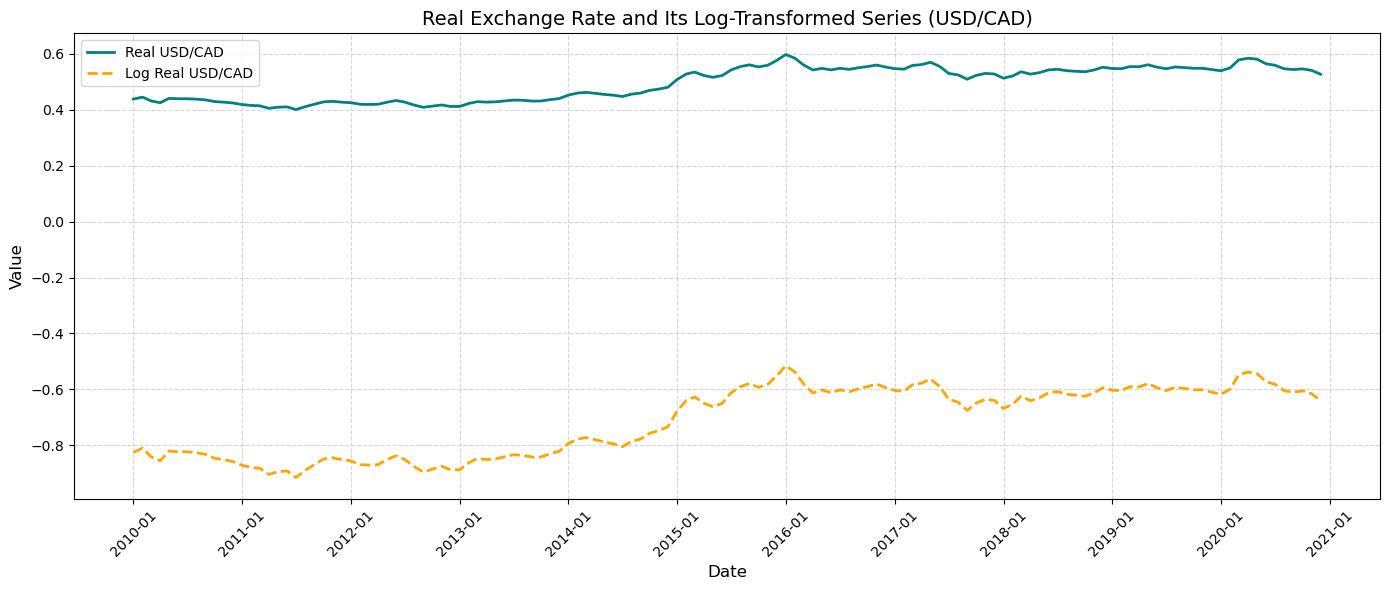

In [97]:
# Plot real exchange rate and its log-transformed version
plt.figure(figsize=(14, 6))


plt.plot(merged_df['DATE'], merged_df['Real_USD_CAD'], label='Real USD/CAD', color='teal', linewidth=2)
plt.plot(merged_df['DATE'], merged_df['lnReal_USD_CAD'], label='Log Real USD/CAD', color='orange', linewidth=2, linestyle='--')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.title("Real Exchange Rate and Its Log-Transformed Series (USD/CAD)", fontsize=14)

# X-axis date formatting
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

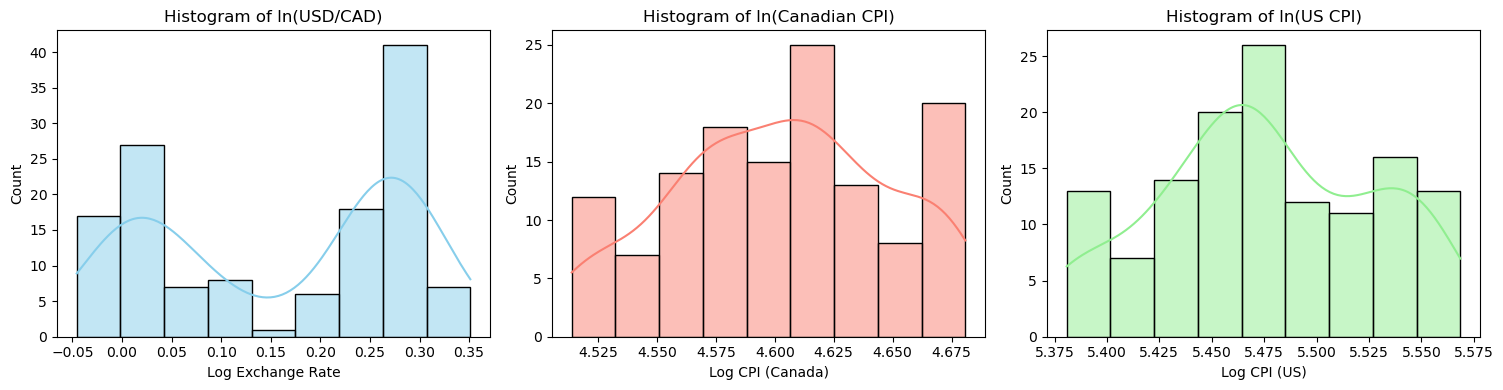

In [99]:
plt.figure(figsize=(15, 4))

# Histogram for ln(USD/CAD)
plt.subplot(1, 3, 1)
sns.histplot(merged_df['lnUSD_CAD'], kde=True, color='skyblue')
plt.title("Histogram of ln(USD/CAD)")
plt.xlabel("Log Exchange Rate")

# Histogram for ln(Canadian CPI)
plt.subplot(1, 3, 2)
sns.histplot(merged_df['lnCan_CPI'], kde=True, color='salmon')
plt.title("Histogram of ln(Canadian CPI)")
plt.xlabel("Log CPI (Canada)")

# Histogram for ln(US CPI)
plt.subplot(1, 3, 3)
sns.histplot(merged_df['lnUs_CPI'], kde=True, color='lightgreen')
plt.title("Histogram of ln(US CPI)")
plt.xlabel("Log CPI (US)")

plt.tight_layout()
plt.show()


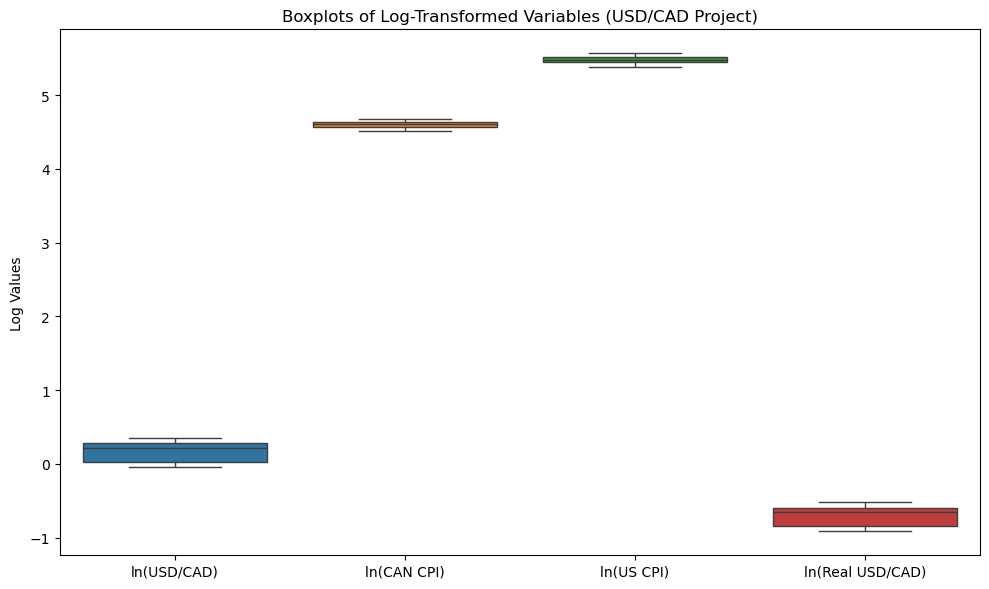

In [101]:
# Create boxplots for your log-transformed variables
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df[['lnUSD_CAD', 'lnCan_CPI', 'lnUs_CPI', 'lnReal_USD_CAD']])

plt.title("Boxplots of Log-Transformed Variables (USD/CAD Project)")
plt.ylabel("Log Values")
plt.xticks([0, 1, 2, 3], ['ln(USD/CAD)', 'ln(CAN CPI)', 'ln(US CPI)', 'ln(Real USD/CAD)'])

plt.tight_layout()
plt.show()

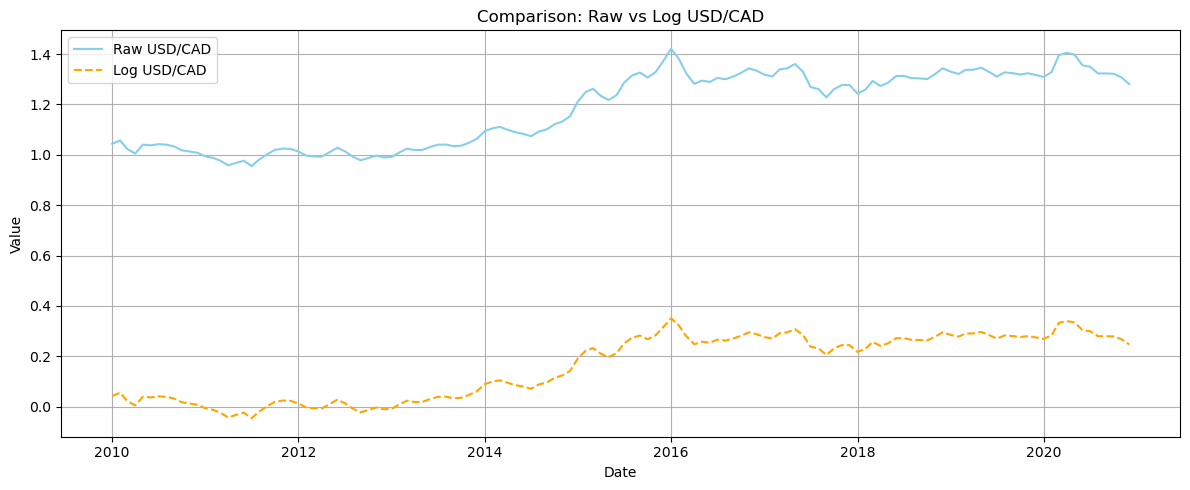

In [103]:
plt.figure(figsize=(12, 5))
plt.plot(merged_df['DATE'], merged_df['USD_CAD'], label='Raw USD/CAD', color='skyblue')
plt.plot(merged_df['DATE'], merged_df['lnUSD_CAD'], label='Log USD/CAD', color='orange', linestyle='--')
plt.title("Comparison: Raw vs Log USD/CAD")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Stationarity (Unit Root Testing)

Ensure that the series are stationary using Augmented Dickey–Fuller (ADF) test on log data.

In [106]:
from statsmodels.tsa.stattools import adfuller

#Define a function to run and display ADF test results
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\nADF Test for {name}")
    print("-" * 40)
    print(f"Test Statistic : {result[0]:.4f}")
    print(f"p-value        : {result[1]:.4f}")
    print(f"Lags Used      : {result[2]}")
    print(f"No. of Obs     : {result[3]}")
    for key, value in result[4].items():
        print(f"Critical Value ({key}) : {value:.4f}")
    if result[1] < 0.05:
        print("=> Conclusion   : Stationary (Reject H₀)")
    else:
        print("=> Conclusion   : Non-stationary (Fail to reject H₀)")


In [108]:
# Run ADF tests on all important series
adf_test(merged_df['lnUSD_CAD'], 'ln(USD/CAD)')
adf_test(merged_df['lnCan_CPI'], 'ln(Canadian CPI)')
adf_test(merged_df['lnUs_CPI'], 'ln(US CPI)')
adf_test(merged_df['lnReal_USD_CAD'], 'ln(Real USD/CAD)')



ADF Test for ln(USD/CAD)
----------------------------------------
Test Statistic : -1.0389
p-value        : 0.7388
Lags Used      : 3
No. of Obs     : 128
Critical Value (1%) : -3.4825
Critical Value (5%) : -2.8844
Critical Value (10%) : -2.5790
=> Conclusion   : Non-stationary (Fail to reject H₀)

ADF Test for ln(Canadian CPI)
----------------------------------------
Test Statistic : -0.9761
p-value        : 0.7619
Lags Used      : 13
No. of Obs     : 118
Critical Value (1%) : -3.4870
Critical Value (5%) : -2.8864
Critical Value (10%) : -2.5800
=> Conclusion   : Non-stationary (Fail to reject H₀)

ADF Test for ln(US CPI)
----------------------------------------
Test Statistic : -0.4614
p-value        : 0.8993
Lags Used      : 2
No. of Obs     : 129
Critical Value (1%) : -3.4821
Critical Value (5%) : -2.8842
Critical Value (10%) : -2.5789
=> Conclusion   : Non-stationary (Fail to reject H₀)

ADF Test for ln(Real USD/CAD)
----------------------------------------
Test Statistic : -1.091

Hypotheses Used:
H₀: Series has a unit root (non-stationary)

H₁: Series is stationary

If p-value < 0.05 - Reject H₀ - Stationary

We used the ADF test to check if our data is stable over time. The hypotheses are: H₀ – the series is non-stationary (has a unit root), and H₁ – the series is stationary. Since all p-values were above 0.05, we failed to reject H₀ and therefore first-differencing is required before conducting further time series modeling or relative PPP testing.

In [110]:
#Transform the non-stationary series to their first-differences:
merged_df['d_lnUSD_CAD'] = merged_df['lnUSD_CAD'].diff()
merged_df['d_lnCan_CPI'] = merged_df['lnCan_CPI'].diff()
merged_df['d_lnUs_CPI'] = merged_df['lnUs_CPI'].diff()
merged_df['d_inflation_diff'] = merged_df['d_lnCan_CPI'] - merged_df['d_lnUs_CPI']

In [112]:
# Run ADF tests on differenced series
adf_test(merged_df['d_lnUSD_CAD'], 'd_ ln(USD/CAD)')
adf_test(merged_df['d_lnCan_CPI'], 'd_ ln(Canadian CPI)')
adf_test(merged_df['d_lnUs_CPI'], 'd_ ln(US CPI)')
adf_test(merged_df['d_inflation_diff'], 'd_ Inflation Differential')



ADF Test for d_ ln(USD/CAD)
----------------------------------------
Test Statistic : -7.5914
p-value        : 0.0000
Lags Used      : 2
No. of Obs     : 128
Critical Value (1%) : -3.4825
Critical Value (5%) : -2.8844
Critical Value (10%) : -2.5790
=> Conclusion   : Stationary (Reject H₀)

ADF Test for d_ ln(Canadian CPI)
----------------------------------------
Test Statistic : -3.0940
p-value        : 0.0270
Lags Used      : 13
No. of Obs     : 117
Critical Value (1%) : -3.4875
Critical Value (5%) : -2.8866
Critical Value (10%) : -2.5801
=> Conclusion   : Stationary (Reject H₀)

ADF Test for d_ ln(US CPI)
----------------------------------------
Test Statistic : -7.5417
p-value        : 0.0000
Lags Used      : 1
No. of Obs     : 129
Critical Value (1%) : -3.4821
Critical Value (5%) : -2.8842
Critical Value (10%) : -2.5789
=> Conclusion   : Stationary (Reject H₀)

ADF Test for d_ Inflation Differential
----------------------------------------
Test Statistic : -2.5598
p-value        :

The differenced series became stationary after transformation. However, the differenced inflation gap is still non-stationary with a p-value of 0.1016. As per unit root testing guideline, which states that only stationary data can be used for regression analysis, we applied a second differencing to make the series stationary

In [114]:
# Second difference of inflation differential
merged_df['d2_inflation_diff'] = merged_df['d_inflation_diff'].diff()

In [116]:
# Run ADF test on second differenced series
adf_test(merged_df['d2_inflation_diff'], 'd2 Inflation Differential')


ADF Test for d2 Inflation Differential
----------------------------------------
Test Statistic : -8.7226
p-value        : 0.0000
Lags Used      : 11
No. of Obs     : 118
Critical Value (1%) : -3.4870
Critical Value (5%) : -2.8864
Critical Value (10%) : -2.5800
=> Conclusion   : Stationary (Reject H₀)


PURCHASE POWER PARITY 

ABSOLUTE PPP

In [118]:
#Absolute PPP

import statsmodels.api as sm

# Set up regression
X_abs_ppp = sm.add_constant(merged_df['inflation_diff'])  # independent variable + intercept
y_abs_ppp = merged_df['lnUSD_CAD']  # dependent variable

# Fit OLS model
model_abs_ppp = sm.OLS(y_abs_ppp, X_abs_ppp).fit()

# : Print summary
print(model_abs_ppp.summary())

                            OLS Regression Results                            
Dep. Variable:              lnUSD_CAD   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     28.79
Date:                Sun, 06 Apr 2025   Prob (F-statistic):           3.57e-07
Time:                        12:24:16   Log-Likelihood:                 99.687
No. Observations:                 132   AIC:                            -195.4
Df Residuals:                     130   BIC:                            -189.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -5.4271      1.041     -5.

RELATIVE PPP

In [120]:
import statsmodels.api as sm

# Drop NA values from the required differenced series
rel_ppp_df = merged_df.dropna(subset=['d_lnUSD_CAD', 'd2_inflation_diff'])

# Set up regression
X_rel_ppp = sm.add_constant(rel_ppp_df['d2_inflation_diff'])  # independent variable
y_rel_ppp = rel_ppp_df['d_lnUSD_CAD']                          # dependent variable

# Fit the model
model_rel_ppp = sm.OLS(y_rel_ppp, X_rel_ppp).fit()

# Show the result
print(model_rel_ppp.summary())

                            OLS Regression Results                            
Dep. Variable:            d_lnUSD_CAD   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     2.137
Date:                Sun, 06 Apr 2025   Prob (F-statistic):              0.146
Time:                        12:24:32   Log-Likelihood:                 344.93
No. Observations:                 130   AIC:                            -685.9
Df Residuals:                     128   BIC:                            -680.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0015      0.00

The Relative PPP test produced a coefficient of 0.5288 with a p-value of 0.146, indicating a weak and statistically insignificant relationship between exchange rate changes and inflation differentials, thus suggesting that Relative PPP does not hold.

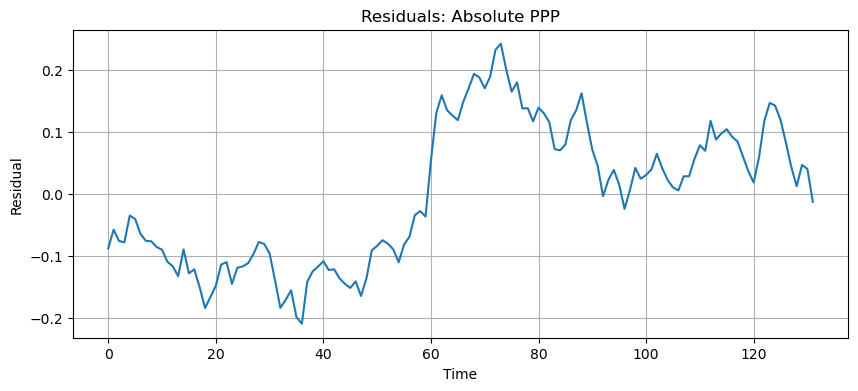

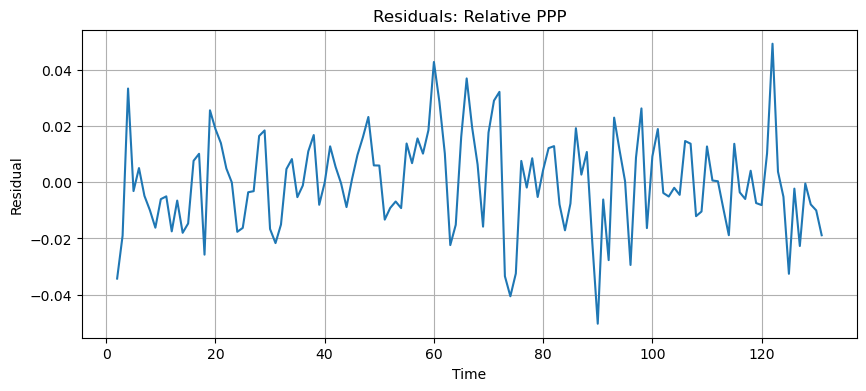

In [122]:
#Residual plot Absolute and Relative PPP
import matplotlib.pyplot as plt

# Absolute PPP residuals
plt.figure(figsize=(10,4))
plt.plot(model_abs_ppp.resid)
plt.title("Residuals: Absolute PPP")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

# Relative PPP residuals
plt.figure(figsize=(10,4))
plt.plot(model_rel_ppp.resid)
plt.title("Residuals: Relative PPP")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)
plt.show()


Based on the analysis, neither Absolute nor Relative PPP holds for the USD/CAD pair from 2010–2020. 

BOX-JENKINS MODELLING

Step A : ADF Test to check for stationary

In [126]:
from statsmodels.tsa.stattools import adfuller

# Step A: ADF test for lnReal_USD_CAD
result = adfuller(merged_df['lnReal_USD_CAD'].dropna())

print("ADF Test for lnReal_USD_CAD")
print(f"Test Statistic : {result[0]:.4f}")
print(f"p-value        : {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] < 0.05:
    print("Series is stationary (Reject H₀)")
else:
    print("Series is non-stationary (Fail to reject H₀)")


ADF Test for lnReal_USD_CAD
Test Statistic : -1.0914
p-value        : 0.7185
Critical Values:
   1%: -3.4825
   5%: -2.8844
   10%: -2.5790
Series is non-stationary (Fail to reject H₀)


In [128]:
# First difference
merged_df['d_lnReal_USD_CAD'] = merged_df['lnReal_USD_CAD'].diff()

# ADF test on differenced series
from statsmodels.tsa.stattools import adfuller

result_diff = adfuller(merged_df['d_lnReal_USD_CAD'].dropna())

print("ADF Test for d_lnReal_USD_CAD")
print(f"Test Statistic : {result_diff[0]:.4f}")
print(f"p-value        : {result_diff[1]:.4f}")
print("Critical Values:")
for key, value in result_diff[4].items():
    print(f"   {key}: {value:.4f}")

if result_diff[1] < 0.05:
    print("Series is now stationary (Reject H₀)")
else:
    print("Still non-stationary (Fail to reject H₀)")

ADF Test for d_lnReal_USD_CAD
Test Statistic : -7.3138
p-value        : 0.0000
Critical Values:
   1%: -3.4825
   5%: -2.8844
   10%: -2.5790
Series is now stationary (Reject H₀)


Step B : Model Identification (ACF and PACF Analysis)

<Figure size 1000x400 with 0 Axes>

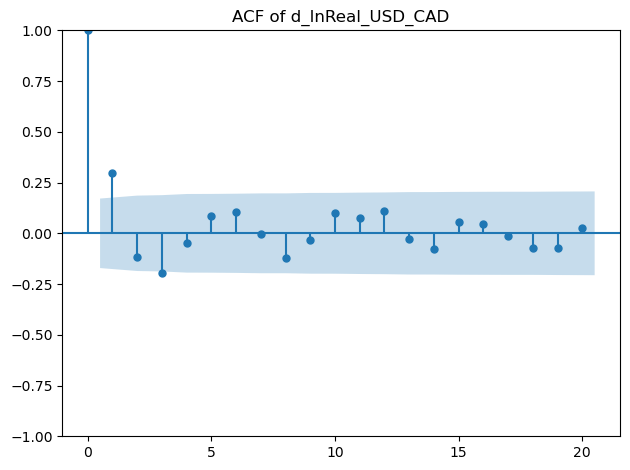

<Figure size 1000x400 with 0 Axes>

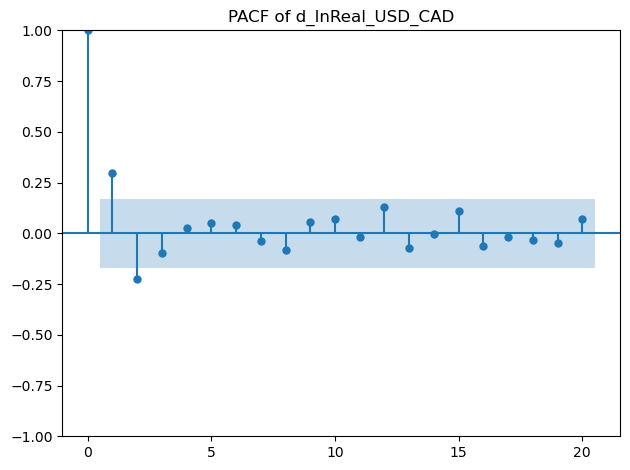

In [130]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Drop missing values from the differenced series
d_series = merged_df['d_lnReal_USD_CAD'].dropna()

# Plot ACF
plt.figure(figsize=(10, 4))
plot_acf(d_series, lags=20)
plt.title("ACF of d_lnReal_USD_CAD")
plt.tight_layout()
plt.show()

# Plot PACF
plt.figure(figsize=(10, 4))
plot_pacf(d_series, lags=20)
plt.title("PACF of d_lnReal_USD_CAD")
plt.tight_layout()
plt.show()

The ACF showed a significant spike at lag 1 and dropped off, suggesting a Moving Average (MA) component.
The PACF also had a strong lag 1 spike and dropped quickly, indicating an Autoregressive (AR) structure.

Step C : ARIMA 

In [134]:
from statsmodels.tsa.arima.model import ARIMA

# drop NA 
series = merged_df['lnReal_USD_CAD'].dropna()

# Dictionary to store results
model_results = {}

# List of models to estimate
model_orders = {
    "ARIMA(1,1,0)": (1, 1, 0),
    "ARIMA(0,1,1)": (0, 1, 1),
    "ARIMA(1,1,1)": (1, 1, 1),
    "ARIMA(2,1,0)": (2, 1, 0),
    "ARIMA(0,1,2)": (0, 1, 2),
    "ARIMA(2,1,1)": (2, 1, 1)
}

# Estimate and store models
for name, order in model_orders.items():
    model = ARIMA(series, order=order).fit()
    model_results[name] = model
    print(f"\n{name} Summary:")
    print(model.summary())



ARIMA(1,1,0) Summary:
                               SARIMAX Results                                
Dep. Variable:         lnReal_USD_CAD   No. Observations:                  132
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 348.192
Date:                Sun, 06 Apr 2025   AIC                           -692.383
Time:                        12:27:18   BIC                           -686.633
Sample:                             0   HQIC                          -690.046
                                - 132                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3067      0.077      4.000      0.000       0.156       0.457
sigma2         0.0003   3.35e-05      8.580      0.000       0.000       0.000
Ljung-Box (L1) (Q):          

Six ARIMA models were estimated and compared using AIC, BIC, and t-tests for coefficient significance (α = 5%).

Models with p > 0.05 were rejected as too large. Based on AIC and coefficient significance, we selected three models:  
ARIMA(2,1,0), ARIMA(0,1,1), and ARIMA(1,1,0).

These models will be further validated in Step D.

Step D: Ljung-Box Q Test


 Residual Diagnostics for ARIMA(2,1,0)


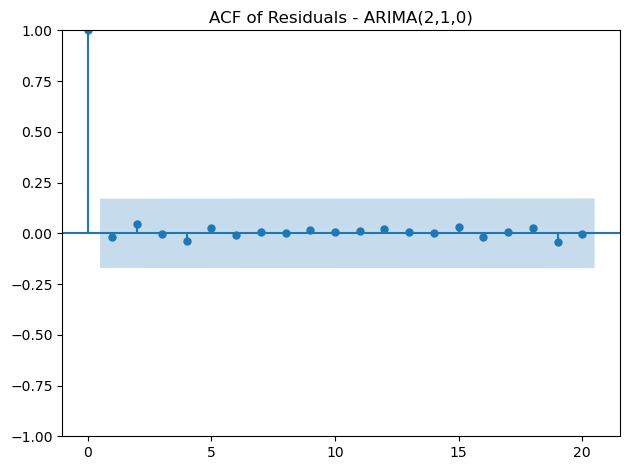

Ljung-Box Test p-value (lag 10): 1.0000
 Residuals are Not autocorrelated

 Residual Diagnostics for ARIMA(0,1,1)


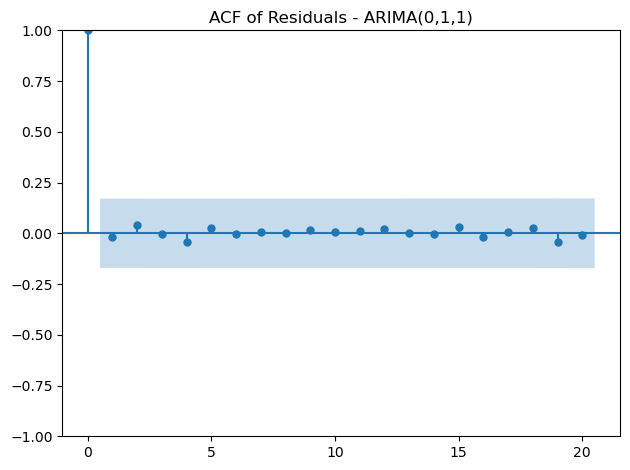

Ljung-Box Test p-value (lag 10): 1.0000
 Residuals are Not autocorrelated

 Residual Diagnostics for ARIMA(1,1,0)


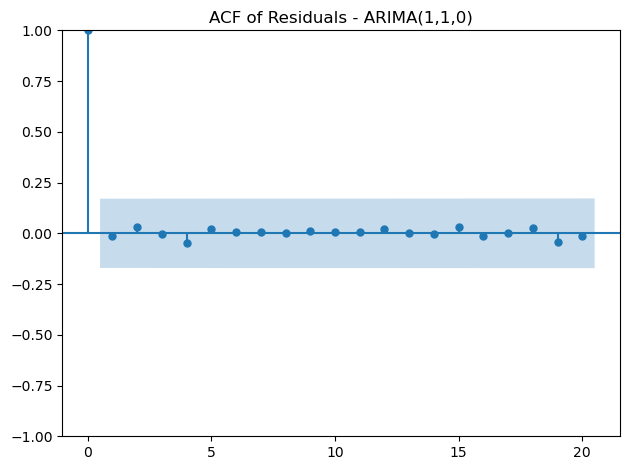

Ljung-Box Test p-value (lag 10): 1.0000
 Residuals are Not autocorrelated


In [136]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# List of models to check
models_to_check = ['ARIMA(2,1,0)', 'ARIMA(0,1,1)', 'ARIMA(1,1,0)']

for model_name in models_to_check:
    model = model_results[model_name]
    residuals = model.resid.dropna()
    
    print(f"\n Residual Diagnostics for {model_name}")
    
    # Plot ACF of residuals
    plot_acf(residuals, lags=20)
    plt.title(f"ACF of Residuals - {model_name}")
    plt.tight_layout()
    plt.show()
    
    # Ljung-Box test
    lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
    p_value = lb_test["lb_pvalue"].values[0]
    print(f"Ljung-Box Test p-value (lag 10): {p_value:.4f}")
    
    if p_value > 0.05:
        print(" Residuals are Not autocorrelated")
    else:
        print("Residuals are autocorrelated (Model may be too small)")


All models have p = 1.0000 
So all models passed this test.

Step E: Final Model Selection & Forecasting 

In [138]:
from statsmodels.stats.diagnostic import acorr_ljungbox

#selected models and their names
selected_models = {
    "ARIMA(2,1,0)": model_results["ARIMA(2,1,0)"],
    "ARIMA(0,1,1)": model_results["ARIMA(0,1,1)"],
    "ARIMA(1,1,0)": model_results["ARIMA(1,1,0)"]
}

#summary info
summary_data = []

for name, model in selected_models.items():
    aic = model.aic
    bic = model.bic
    pvalues = model.pvalues
    all_significant = all(p < 0.05 for p in pvalues)
    lb_pvalue = acorr_ljungbox(model.resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0]

    summary_data.append({
        "Model": name,
        "AIC": round(aic, 2),
        "BIC": round(bic, 2),
        "All Coeffs Significant": " Yes" if all_significant else " No",
        "Ljung-Box p-value ": round(lb_pvalue, 4),
    })

#DataFrame
summary_df = pd.DataFrame(summary_data)

# Display table
from tabulate import tabulate
print(tabulate(summary_df, headers='keys', tablefmt='grid'))

+----+--------------+---------+---------+--------------------------+----------------------+
|    | Model        |     AIC |     BIC | All Coeffs Significant   |   Ljung-Box p-value  |
+====+==============+=========+=========+==========================+======================+
|  0 | ARIMA(2,1,0) | -697.48 | -688.85 | Yes                      |                    1 |
+----+--------------+---------+---------+--------------------------+----------------------+
|  1 | ARIMA(0,1,1) | -696.25 | -690.5  | Yes                      |                    1 |
+----+--------------+---------+---------+--------------------------+----------------------+
|  2 | ARIMA(1,1,0) | -692.38 | -686.63 | Yes                      |                    1 |
+----+--------------+---------+---------+--------------------------+----------------------+


Among the three models, ARIMA(2,1,0) has the lowest AIC (-697.48) and lowest BIC (-688.85), while all coefficients are significant and the Ljung-Box p-value indicates no autocorrelation. Therefore, ARIMA(2,1,0)is selected as the best model for forecasting.

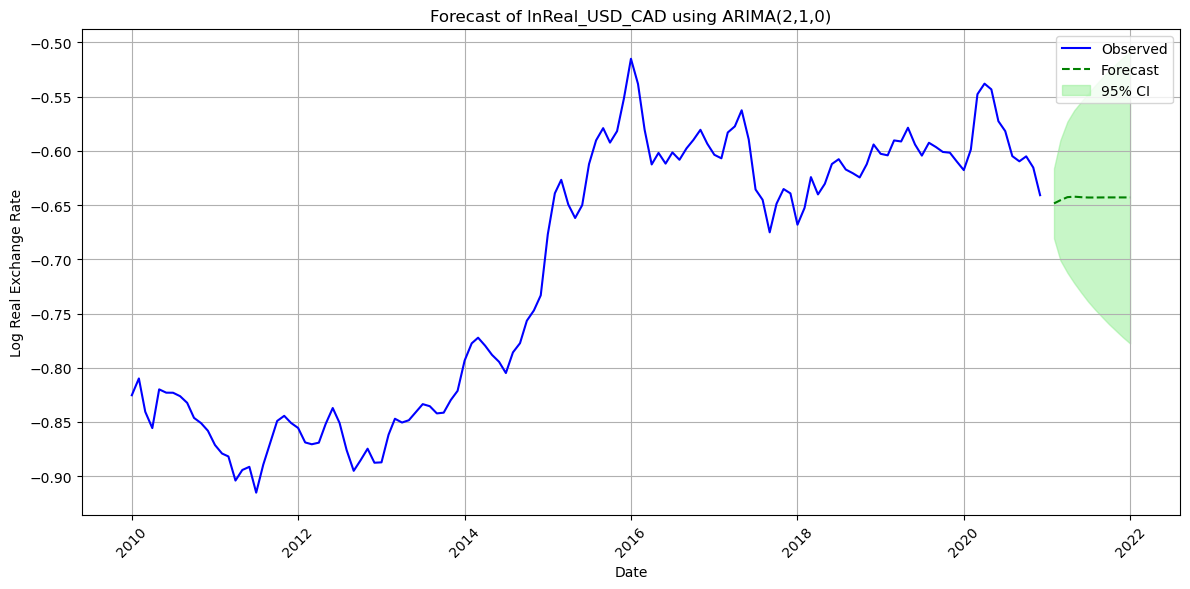

In [140]:
model_210 = model_results["ARIMA(2,1,0)"]

# Forecast next 12 months
forecast_steps = 12
forecast_result = model_210.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Create forecast date range
last_date = merged_df['DATE'].iloc[-1]
forecast_index = pd.date_range(start=pd.to_datetime(last_date) + pd.offsets.MonthBegin(1), periods=forecast_steps, freq='ME')

# Plot forecast with confidence intervals
plt.figure(figsize=(12, 6))
plt.plot(merged_df['DATE'], merged_df['lnReal_USD_CAD'], label="Observed", color='blue')
plt.plot(forecast_index, forecast_mean, label="Forecast", color='green', linestyle='--')
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='lightgreen', alpha=0.5, label="95% CI")

plt.title("Forecast of lnReal_USD_CAD using ARIMA(2,1,0)")
plt.xlabel("Date")
plt.ylabel("Log Real Exchange Rate")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [142]:
# Combine forecast with date
forecast_df = pd.DataFrame({
    "Date": forecast_index,
    "Forecast_lnReal_USD_CAD": forecast_mean.values,
    "Lower_95_CI": conf_int.iloc[:, 0].values,
    "Upper_95_CI": conf_int.iloc[:, 1].values,
})

# Save to CSV
forecast_df.to_csv("forecast_results_dataset.csv", index=False)

In [144]:
merged_df.to_csv("EC6011_Project_Dataset.csv", index=False)